### 데이터시각화   
- 우선 노이즈가 추가되지 않은 원본 데이터로 시각화   

- 참고자료
- [데이터 EDA, 전처리](https://datananalysis.tistory.com/71) 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./credit_risk_dataset.csv") 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


#### 컬럼별 unique 값 확인하기  

In [47]:
df['loan_status'].unique()

array([1, 0])

In [83]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

#### target Y의 클래스 별 퍼센트 나타내기   
- 불균형이 좀 있어서 oversampling이나 undersampling이 있을 수 있다고 생각함 

In [4]:
grade_counts = df['loan_grade'].value_counts()
grade_counts

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

In [5]:
grade_idx = grade_counts.index
print(grade_idx)

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype='object', name='loan_grade')


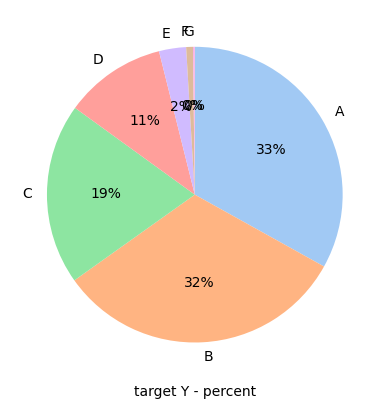

In [6]:
plt.pie(grade_counts, labels=grade_idx, autopct = '%d%%', startangle=90, counterclock=False, colors=sns.color_palette('pastel'))
plt.xlabel('target Y - percent')
plt.show()

#### X변수 중에 object type인거 percent 나타내기 

In [7]:
df.select_dtypes('object').head()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,PERSONAL,D,Y
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y


In [8]:
object_cols = list(df.select_dtypes('object').columns)
object_cols.remove('loan_grade')
object_cols

['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

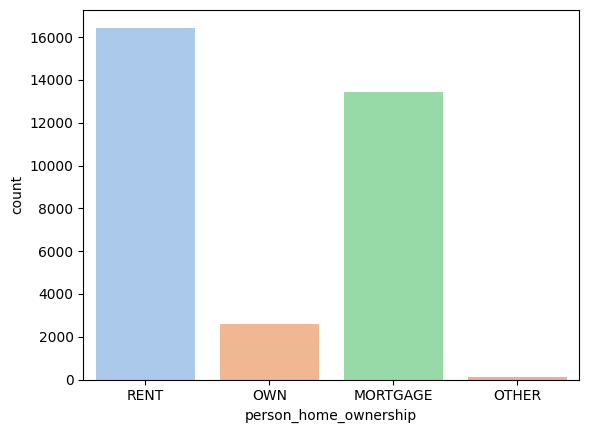

In [9]:
sns.countplot(data=df, x='person_home_ownership', hue = 'person_home_ownership', palette='pastel')
plt.show()

In [10]:
# sns.countplot(data=df, x='loan_intent', hue = 'loan_intent', palette='pastel')
# plt.xticks(rotation=45)
# plt.show()

In [11]:
# sns.countplot(data=df, x='cb_person_default_on_file', hue = 'cb_person_default_on_file', palette='pastel')
# plt.show()

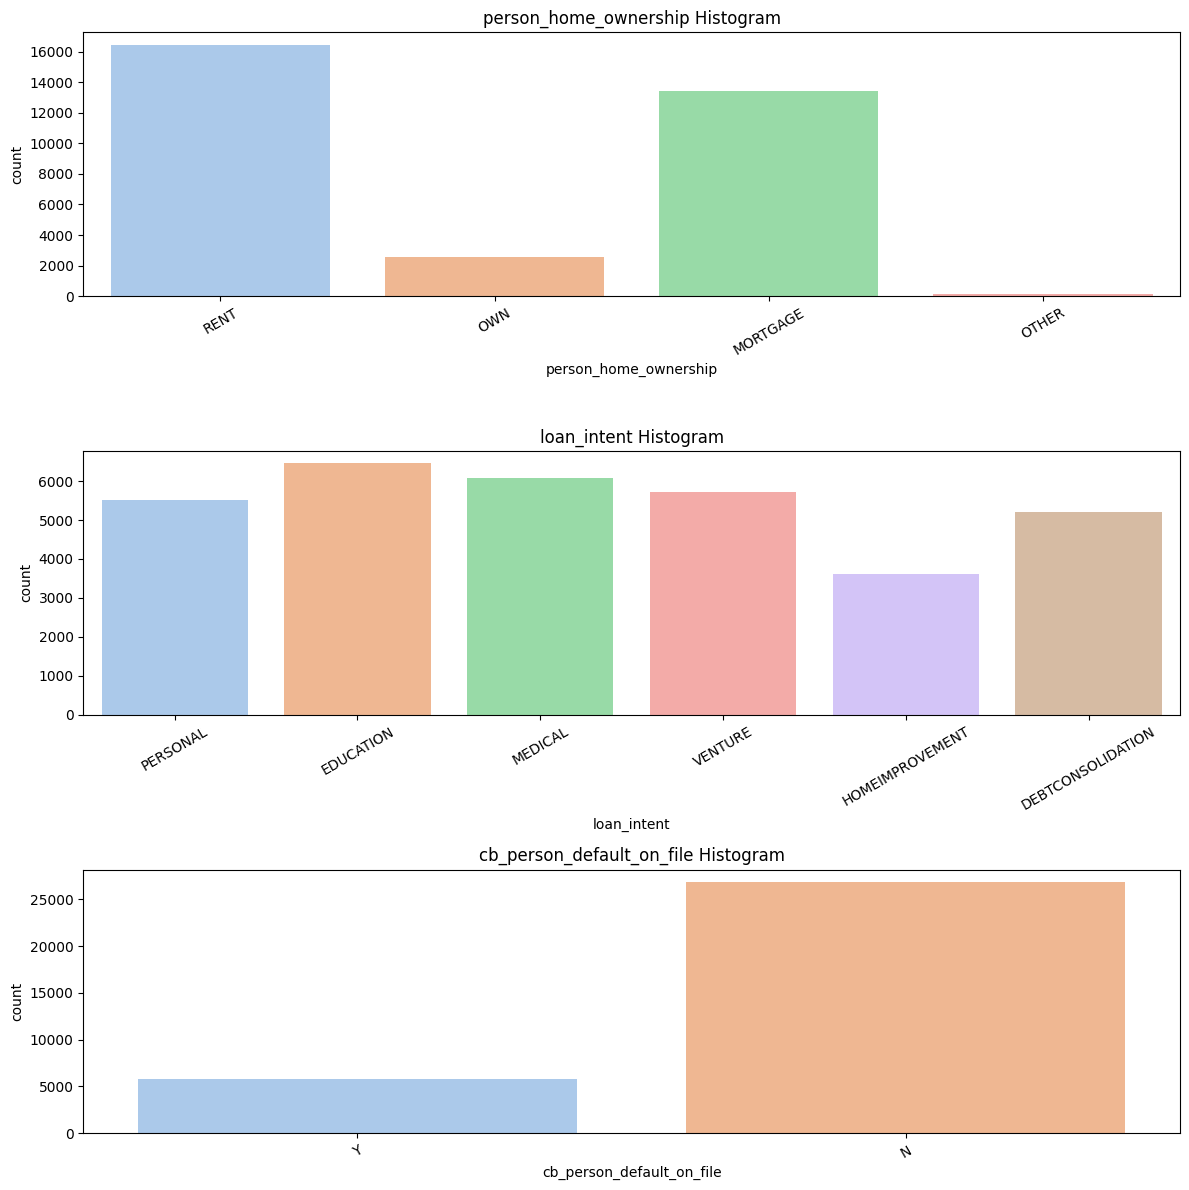

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(object_cols):
    sns.countplot(data=df, x=col, palette='pastel', ax=axes[i], hue=col)
    axes[i].set_title(f'{col} Histogram')
    axes[i].tick_params(axis='x', rotation=30)  # x축 라벨 겹침 방지용

plt.tight_layout()
plt.show()

In [13]:
# sns.countplot(data=df, x='cb_person_default_on_file', hue='loan_grade', palette='pastel')

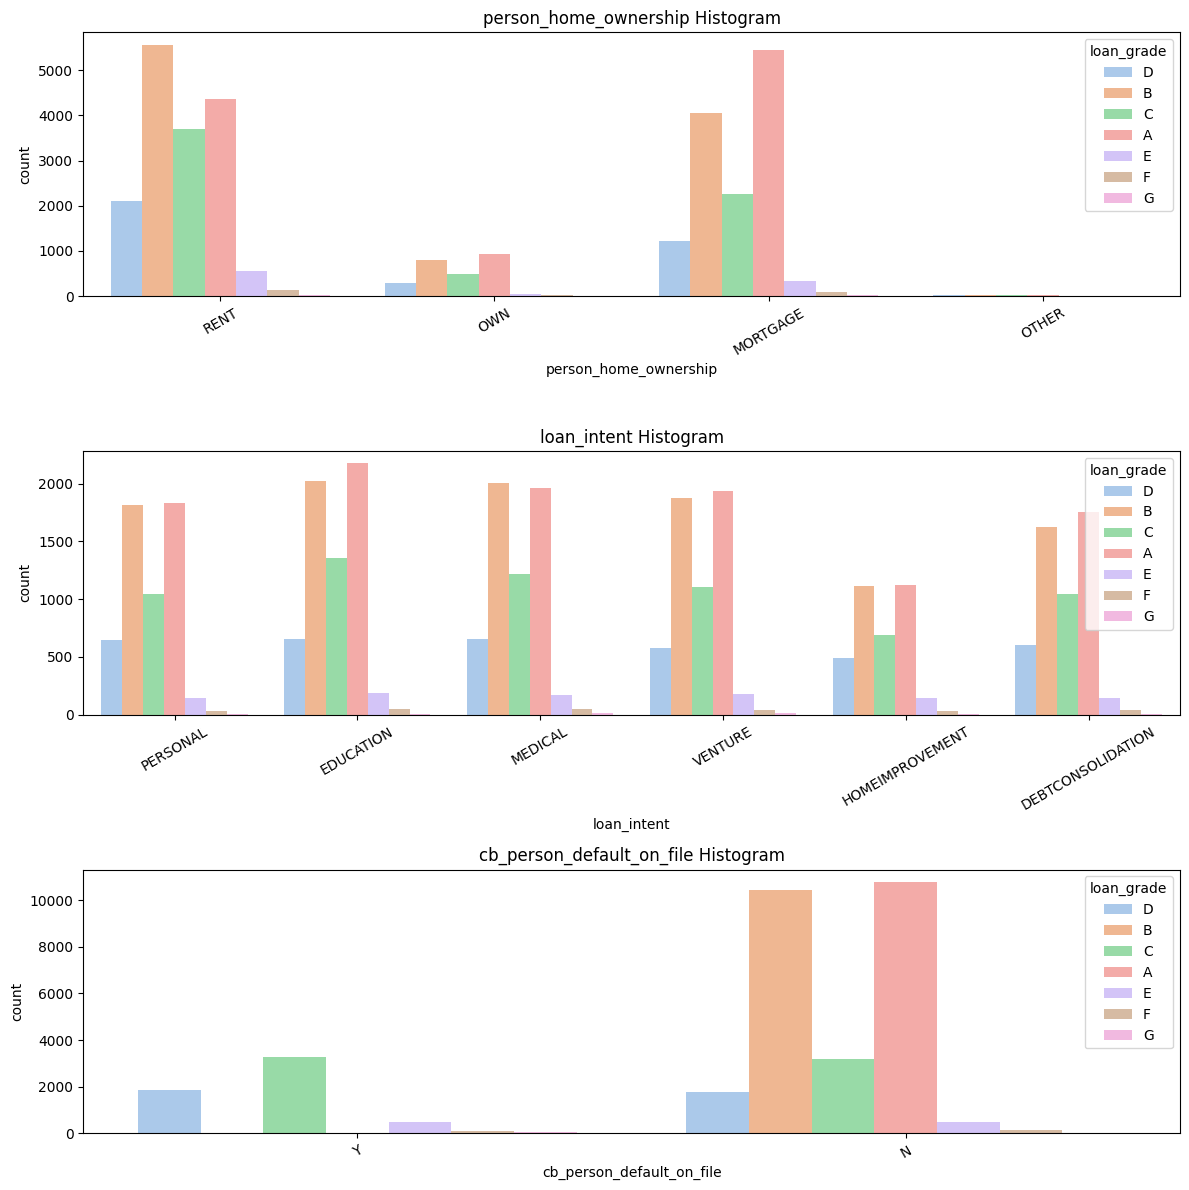

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(object_cols):
    sns.countplot(data=df, x=col, hue='loan_grade', palette='pastel', ax=axes[i])
    axes[i].set_title(f'{col} Histogram')
    axes[i].tick_params(axis='x', rotation=30)  # x축 라벨 겹침 방지용

plt.tight_layout()
plt.show()

#### X변수중에 수치형 데이터의 분포를 파악하기 

In [15]:
df.select_dtypes(['int', 'float']) 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,35000,16.02,1,0.59,3
1,21,9600,5.0,1000,11.14,0,0.10,2
2,25,9600,1.0,5500,12.87,1,0.57,3
3,23,65500,4.0,35000,15.23,1,0.53,2
4,24,54400,8.0,35000,14.27,1,0.55,4
...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30
32577,54,120000,4.0,17625,7.49,0,0.15,19
32578,65,76000,3.0,35000,10.99,1,0.46,28
32579,56,150000,5.0,15000,11.48,0,0.10,26


In [16]:
cols = df.select_dtypes(['int', 'float']).columns

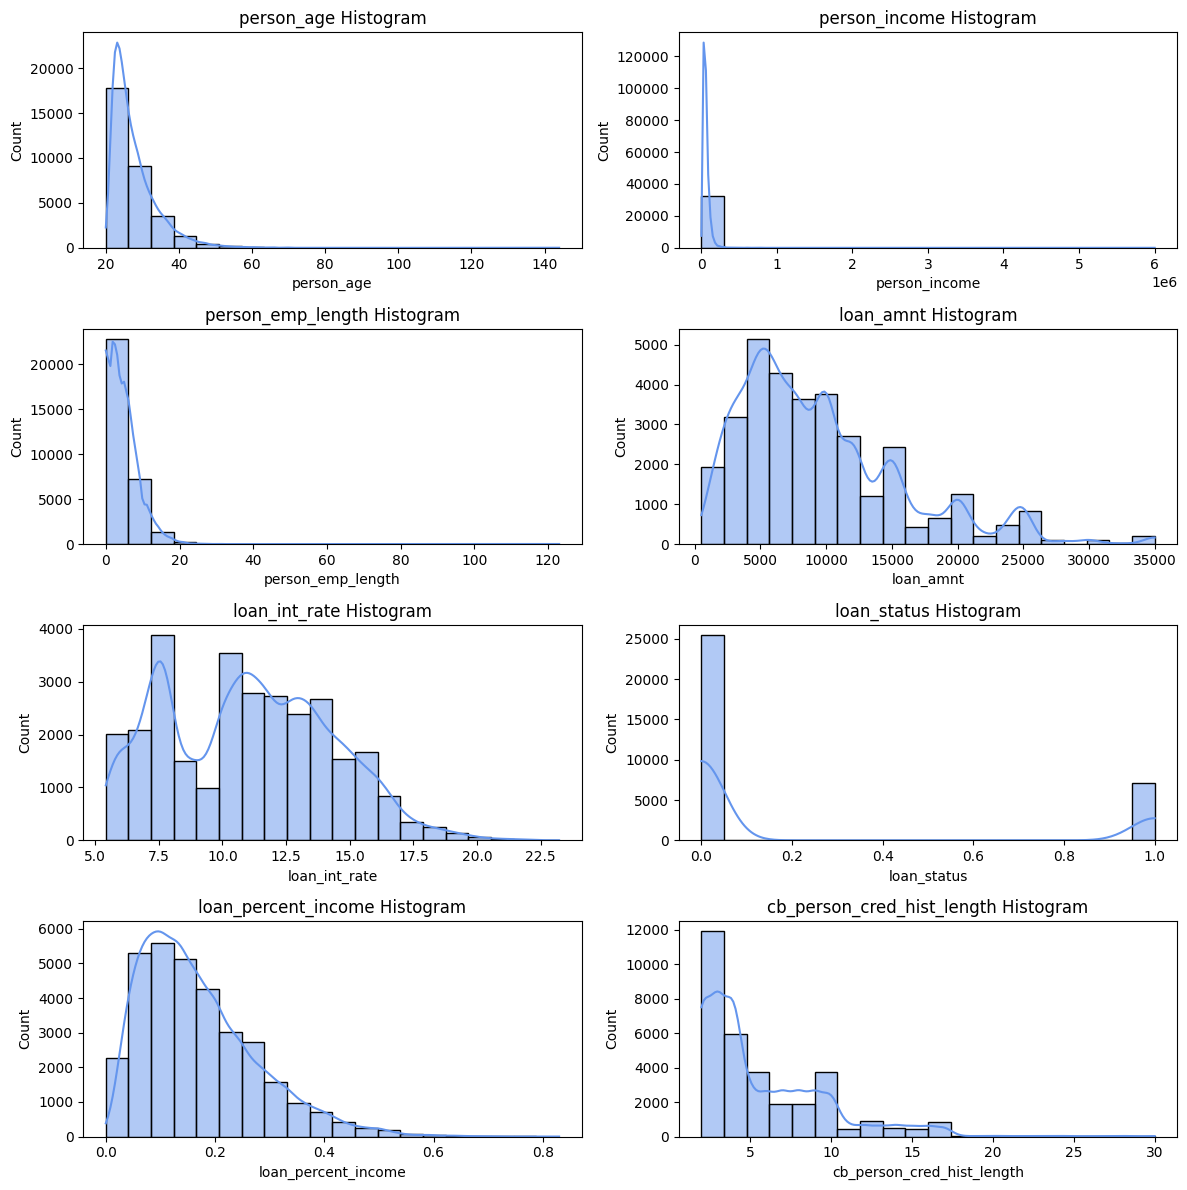

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col} Histogram')

plt.tight_layout()
plt.show()

- person_income은 outlier가 많아서 분포가 잘 안보임
- loan_status는 양쪽으로 분리되는 듯한 느낌의 분포 : 이것도 명목형 변수인듯 ?
- loan_int_rate 변수로 너무 잘 분리가 되고 의미상 신용등급에 따라 결정되는 후순위 값이라 제외하고 학습하는게 맞는 것 같음  

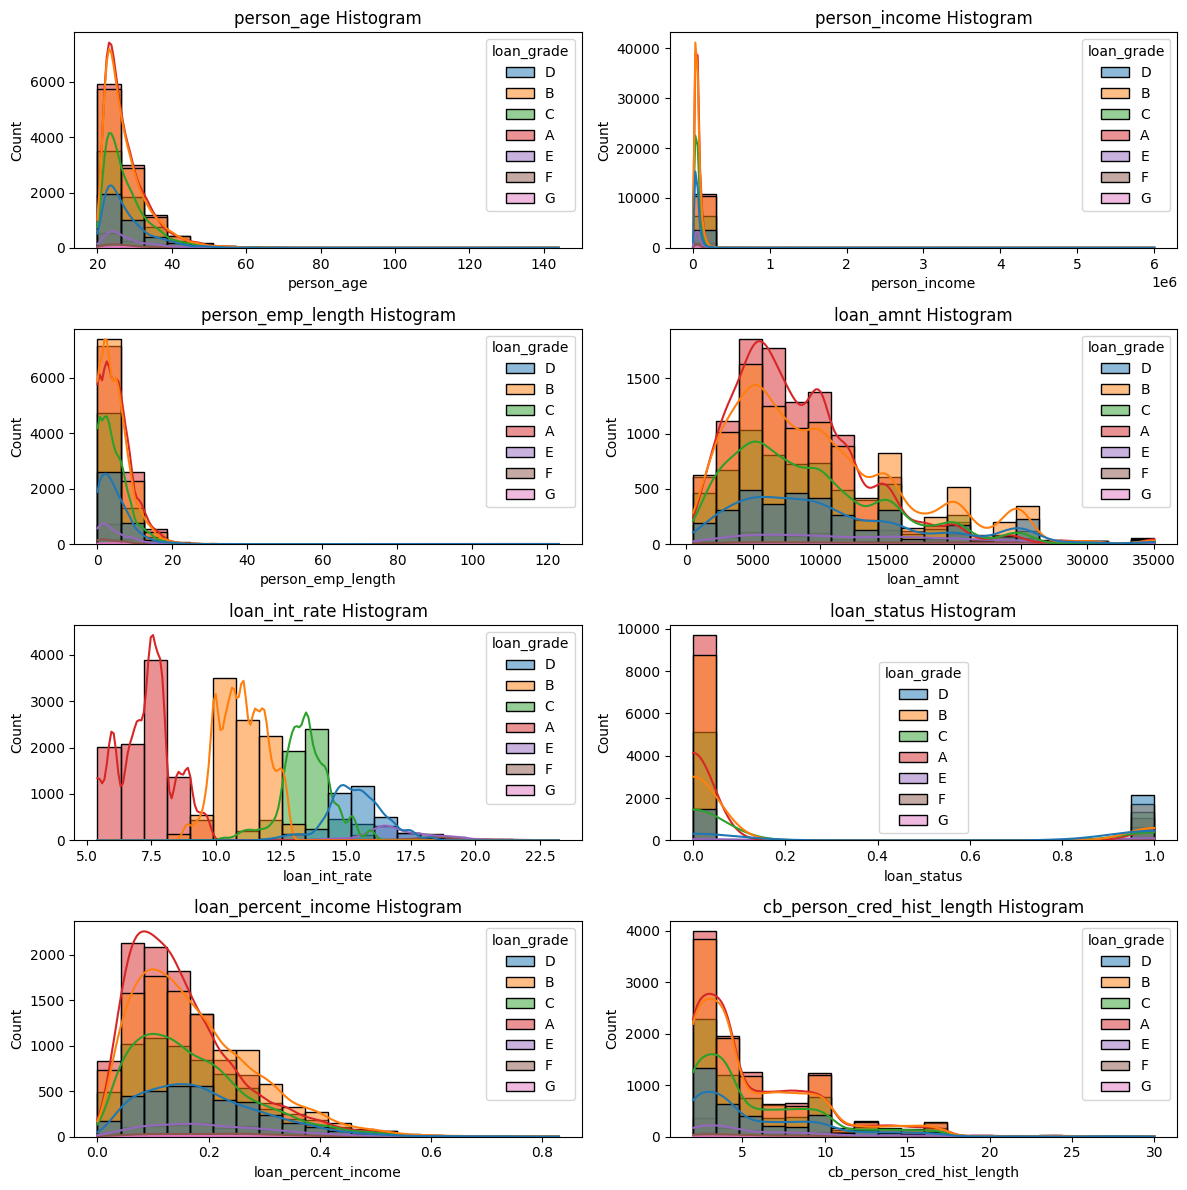

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, hue='loan_grade', bins=20, kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col} Histogram')

plt.tight_layout()
plt.show()

- 아래 시각화 결과 보니까 loan_int_rate 변수를 제거하고 학습해야겠다는 생각이 듦

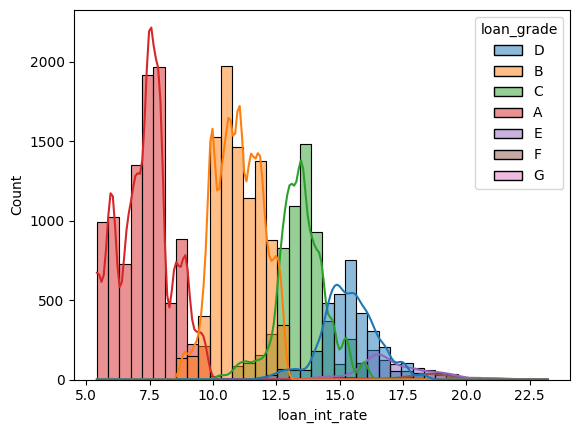

In [19]:
sns.histplot(data=df, x='loan_int_rate', hue='loan_grade', bins=40, kde=True, color='cornflowerblue')  
plt.show()  

In [20]:
# 노이즈 추가 테스트  
df['loan_int_rate_noise'] = df['loan_int_rate'] + np.random.uniform(low=-10, high=10, size=df.shape[0])  

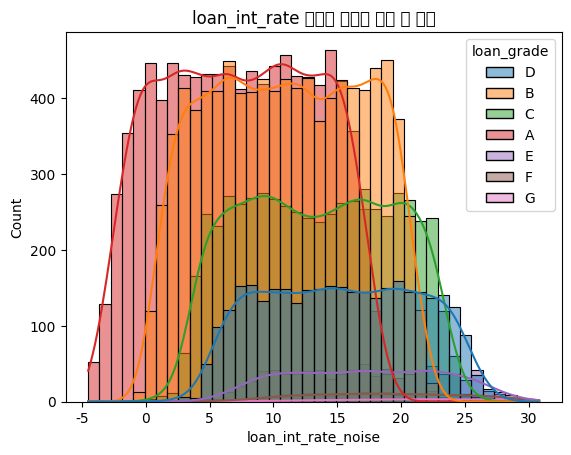

In [21]:
sns.histplot(data=df, x='loan_int_rate_noise', hue='loan_grade', bins=40, kde=True, color='cornflowerblue')
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
plt.title('loan_int_rate 변수에 노이즈 추가 시 분포')
plt.show()

In [22]:
df = df.drop(columns='loan_int_rate_noise')  
df.columns  

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

- 이상치가 있는 컬럼들이 꽤 많음

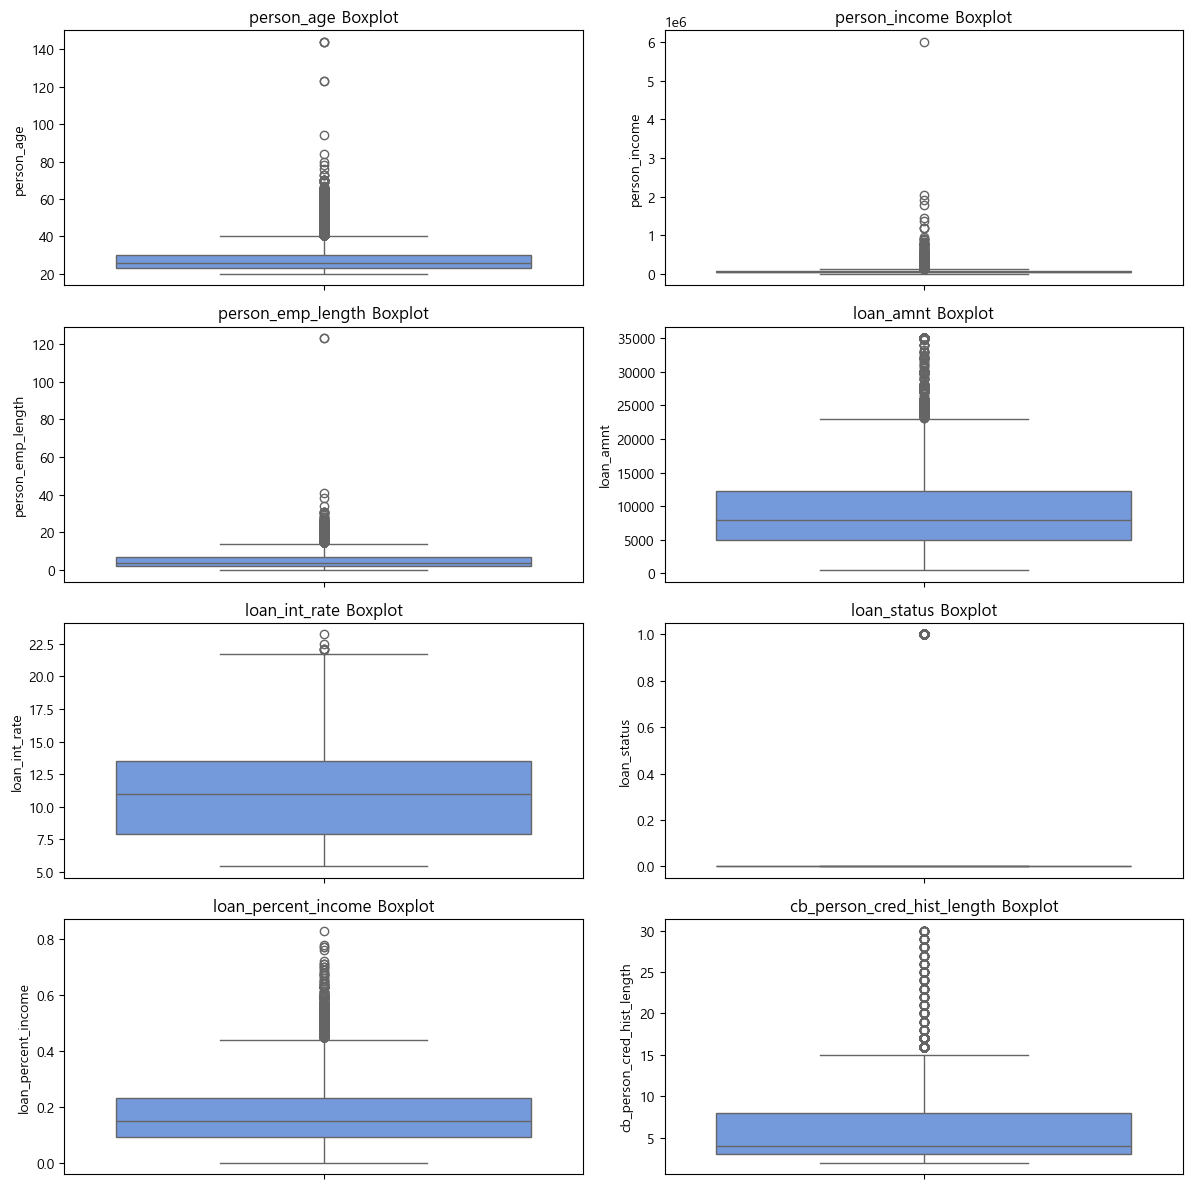

In [23]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, y = col, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

- loan_int_rate 변수가 너무 명확하게 분리되어 있음
- outlier 있는 변수들은 나중에 변경해줘야 하나?
- 변수별로 범위가 상이한 것을 알 수 있음
- outlier 제거 후에 다시 box plot 그려봐야할듯

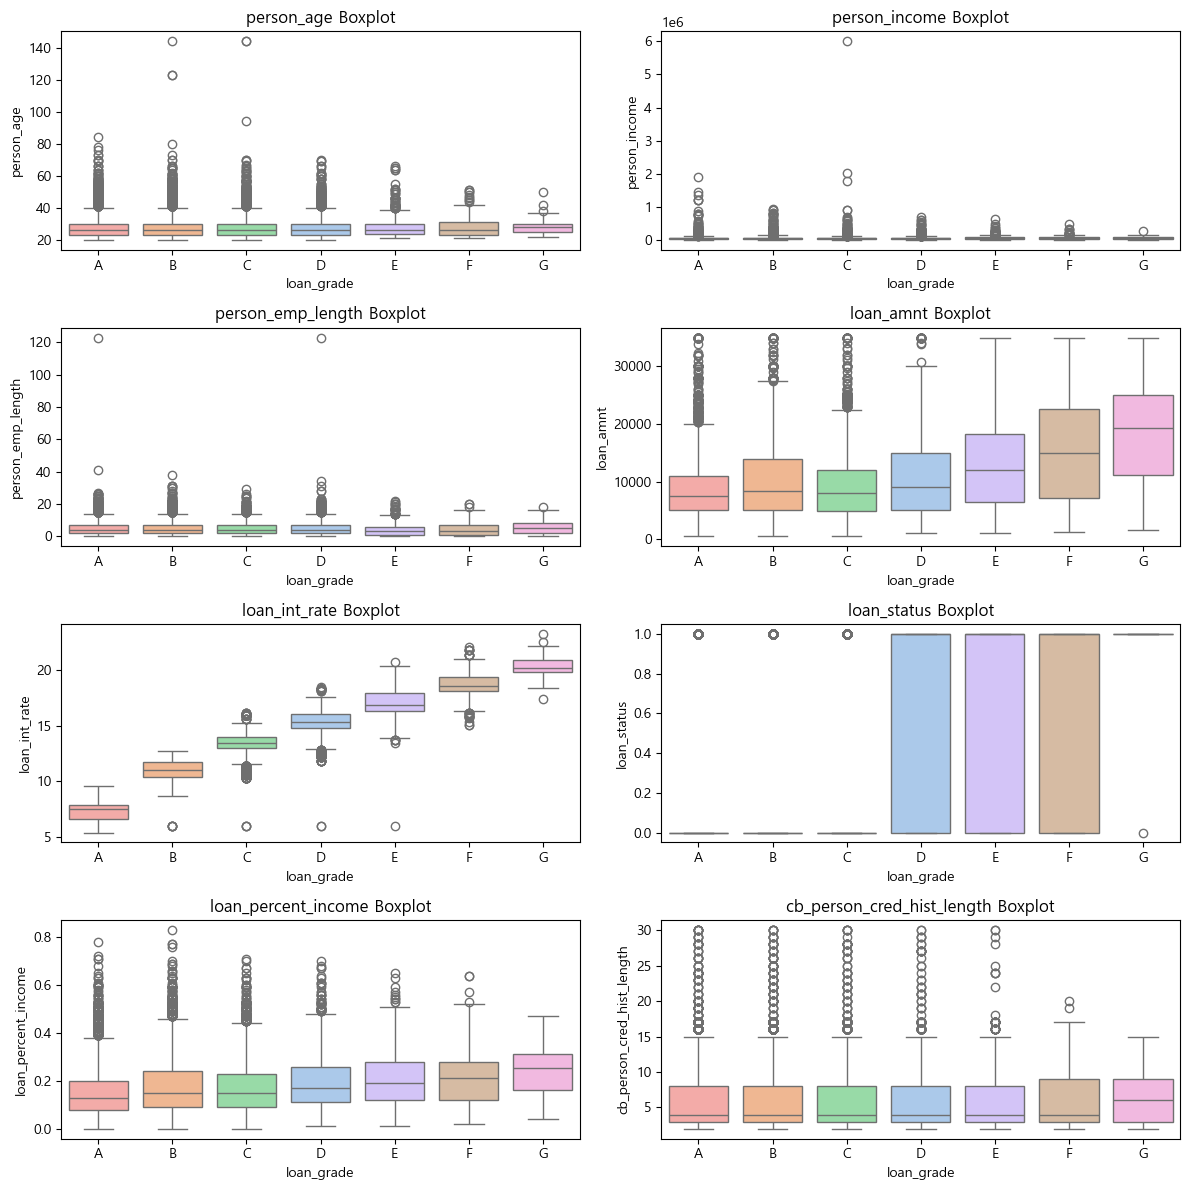

In [24]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()
order = sorted(df['loan_grade'].unique())

for i, col in enumerate(cols):
    sns.boxplot(data=df, x='loan_grade', y=col, ax=axes[i], hue='loan_grade', palette='pastel', order=order)
    axes[i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

#### 변수들 간의 관계 보기    
- 행렬식, 고유값, 상관행렬  

In [25]:
X = df.iloc[:,:]
X.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [26]:
X = X.drop(columns='loan_grade')
X.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


In [27]:
X.shape

(32581, 11)

In [28]:
X = pd.get_dummies(X, dtype=float)
X.shape

(32581, 20)

In [29]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      32581 non-null  int64  
 1   person_income                   32581 non-null  int64  
 2   person_emp_length               31686 non-null  float64
 3   loan_amnt                       32581 non-null  int64  
 4   loan_int_rate                   29465 non-null  float64
 5   loan_status                     32581 non-null  int64  
 6   loan_percent_income             32581 non-null  float64
 7   cb_person_cred_hist_length      32581 non-null  int64  
 8   person_home_ownership_MORTGAGE  32581 non-null  float64
 9   person_home_ownership_OTHER     32581 non-null  float64
 10  person_home_ownership_OWN       32581 non-null  float64
 11  person_home_ownership_RENT      32581 non-null  float64
 12  loan_intent_DEBTCONSOLIDATION   

In [30]:
X.isnull().sum()

person_age                           0
person_income                        0
person_emp_length                  895
loan_amnt                            0
loan_int_rate                     3116
loan_status                          0
loan_percent_income                  0
cb_person_cred_hist_length           0
person_home_ownership_MORTGAGE       0
person_home_ownership_OTHER          0
person_home_ownership_OWN            0
person_home_ownership_RENT           0
loan_intent_DEBTCONSOLIDATION        0
loan_intent_EDUCATION                0
loan_intent_HOMEIMPROVEMENT          0
loan_intent_MEDICAL                  0
loan_intent_PERSONAL                 0
loan_intent_VENTURE                  0
cb_person_default_on_file_N          0
cb_person_default_on_file_Y          0
dtype: int64

In [31]:
X = X.fillna(0)

In [32]:
XtX = X.T@X
XtX

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_N,cb_person_default_on_file_Y
person_age,2.637448e+07,6.192697e+10,4.347265e+06,8.731563e+09,8.999871e+06,1.952900e+05,1.528628e+05,5.965325e+06,3.761730e+05,2868.00,7.157300e+04,4.530070e+05,1.438840e+05,1.715730e+05,1.047850e+05,1.699760e+05,1.557390e+05,1.576640e+05,7.438280e+05,1.597930e+05
person_income,6.192697e+10,2.674143e+14,1.122177e+10,2.405031e+13,2.142565e+10,3.491851e+08,3.115383e+08,1.346138e+10,1.090673e+09,8173495.00,1.494452e+08,9.044930e+08,3.464462e+08,4.138644e+08,2.651458e+08,3.729854e+08,3.746779e+08,3.796648e+08,1.775966e+09,3.768190e+08
person_emp_length,4.347265e+06,1.122177e+10,1.270670e+06,1.560312e+09,1.492313e+06,2.824300e+04,2.498638e+04,9.587850e+05,7.703800e+04,394.00,1.245400e+04,6.188000e+04,2.412800e+04,2.807800e+04,1.802100e+04,2.811200e+04,2.624400e+04,2.718300e+04,1.261960e+05,2.557000e+04
loan_amnt,8.731563e+09,2.405031e+13,1.560312e+09,4.298203e+12,3.198399e+09,7.712538e+07,6.577104e+07,1.848469e+09,1.421630e+08,1184975.00,2.333338e+07,1.457499e+08,5.000855e+07,6.119172e+07,3.734968e+07,5.621492e+07,5.285680e+07,5.480962e+07,2.542726e+08,5.815870e+07
loan_int_rate,8.999871e+06,2.142565e+10,1.492313e+06,3.198399e+09,3.882239e+06,8.442118e+04,5.642155e+04,1.884483e+06,1.271355e+05,1130.88,2.558887e+04,1.706043e+05,5.165431e+04,6.410283e+04,3.685179e+04,6.028912e+04,5.514508e+04,5.641646e+04,2.487991e+05,7.566044e+04
loan_status,1.952900e+05,3.491851e+08,2.824300e+04,7.712538e+07,8.442118e+04,7.108000e+03,1.754890e+03,4.040900e+04,1.690000e+03,33.00,1.930000e+02,5.192000e+03,1.490000e+03,1.111000e+03,9.410000e+02,1.621000e+03,1.098000e+03,8.470000e+02,4.936000e+03,2.172000e+03
loan_percent_income,1.528628e+05,3.115383e+08,2.498638e+04,6.577104e+07,5.642155e+04,1.754890e+03,1.315335e+03,3.173962e+04,2.034460e+03,20.54,4.878000e+02,3.002600e+03,8.903300e+02,1.098200e+03,5.966800e+02,1.050550e+03,9.343200e+02,9.753200e+02,4.519970e+03,1.025430e+03
cb_person_cred_hist_length,5.965325e+06,1.346138e+10,9.587850e+05,1.848469e+09,1.884483e+06,4.040900e+04,3.173962e+04,1.633331e+06,7.962200e+04,570.00,1.516400e+04,9.375100e+04,2.980900e+04,3.330300e+04,2.336700e+04,3.607200e+04,3.380400e+04,3.275200e+04,1.555320e+05,3.357500e+04
person_home_ownership_MORTGAGE,3.761730e+05,1.090673e+09,7.703800e+04,1.421630e+08,1.271355e+05,1.690000e+03,2.034460e+03,7.962200e+04,1.344400e+04,0.00,0.000000e+00,0.000000e+00,2.312000e+03,2.627000e+03,1.741000e+03,2.190000e+03,2.340000e+03,2.234000e+03,1.145000e+04,1.994000e+03
person_home_ownership_OTHER,2.868000e+03,8.173495e+06,3.940000e+02,1.184975e+06,1.130880e+03,3.300000e+01,2.054000e+01,5.700000e+02,0.000000e+00,107.00,0.000000e+00,0.000000e+00,1.700000e+01,1.700000e+01,1.200000e+01,1.700000e+01,1.800000e+01,2.600000e+01,7.800000e+01,2.900000e+01


In [33]:
np.linalg.det(XtX)  # 값이 0이 아니므로 full rank. 0에 가깝지도 않음  

np.float64(-8.191071318454971e+66)

In [34]:
e, v = np.linalg.eig(XtX)
print(e)

[ 2.69594538e+14  2.11793874e+12  8.66992633e+06  7.75852454e+05
  5.33332692e+05  2.16301649e+05  1.37699250e+04  9.05524678e+03
  6.34620817e+03  6.04791669e+03  5.73645483e+03  5.47907939e+03
  4.40972272e+03  3.83734003e+03  3.35328547e+03  6.43731345e+02
  1.26845651e+02  1.50504407e+02  1.35359816e-12 -2.21576781e-14]


In [35]:
X.columns.shape

(20,)

In [36]:
len(e)

20

In [37]:
e[0]  # 고유값이 너무 큰게 변수 범위의 영향이 있을 것 같음  

np.float64(269594537614197.34)

In [38]:
v.shape  

(20, 20)

In [89]:
np.round(v[0].dot(v[0]),2) # 고유벡터 길이 1 (내적값)  

np.float64(1.0)

In [93]:
np.round(v[1].dot(v[1]),2) # 고유벡터 길이 1 (내적값)  

np.float64(1.0)

In [39]:
np.round(v[0].dot(v[1]),2)  # 대칭행렬의 고유벡터끼리는 직교함 (내적값 0)  Q

np.float64(0.0)

In [94]:
np.round(v[1].dot(v[15]),2)  # 대칭행렬의 고유벡터끼리는 직교함 (내적값 0)  Q

np.float64(-0.0)

- person imcome이 영향력이 높은데 outlier가 많아서 그런가 ?

In [40]:
# 아래는 챗지피티
# 변수별 영향력 (고유값 가중합)
influence = np.sum(np.abs(e) * v, axis=1)

# 영향력 높은 순으로 정렬
sorted_idx = np.argsort(influence)[::-1]
important_vars = np.array(X.columns)[sorted_idx]

print("변수 영향력 순서:")
for var, score in zip(important_vars, influence[sorted_idx]):
    print(f"{var}: {score:.4f}")

변수 영향력 순서:
person_income: 268684731166392.2500
loan_amnt: 22230865638726.3906
person_age: 59349712173.0497
loan_int_rate: 20372704753.3451
cb_person_cred_hist_length: 12945619009.5738
person_emp_length: 10775540640.3780
cb_person_default_on_file_N: 1698603473.9790
person_home_ownership_MORTGAGE: 1055906714.5976
person_home_ownership_RENT: 850271728.0375
loan_intent_EDUCATION: 394081949.0359
loan_intent_VENTURE: 362721306.8591
loan_intent_PERSONAL: 359055846.0578
cb_person_default_on_file_Y: 356556965.6052
loan_intent_MEDICAL: 354168678.0650
loan_intent_DEBTCONSOLIDATION: 330978518.5583
loan_status: 309361832.6872
loan_percent_income: 278800710.5577
loan_intent_HOMEIMPROVEMENT: 254154141.0081
person_home_ownership_OWN: 141177698.8611
person_home_ownership_OTHER: 7804298.0880


In [41]:
corr_x = X.corr()  

<Axes: >

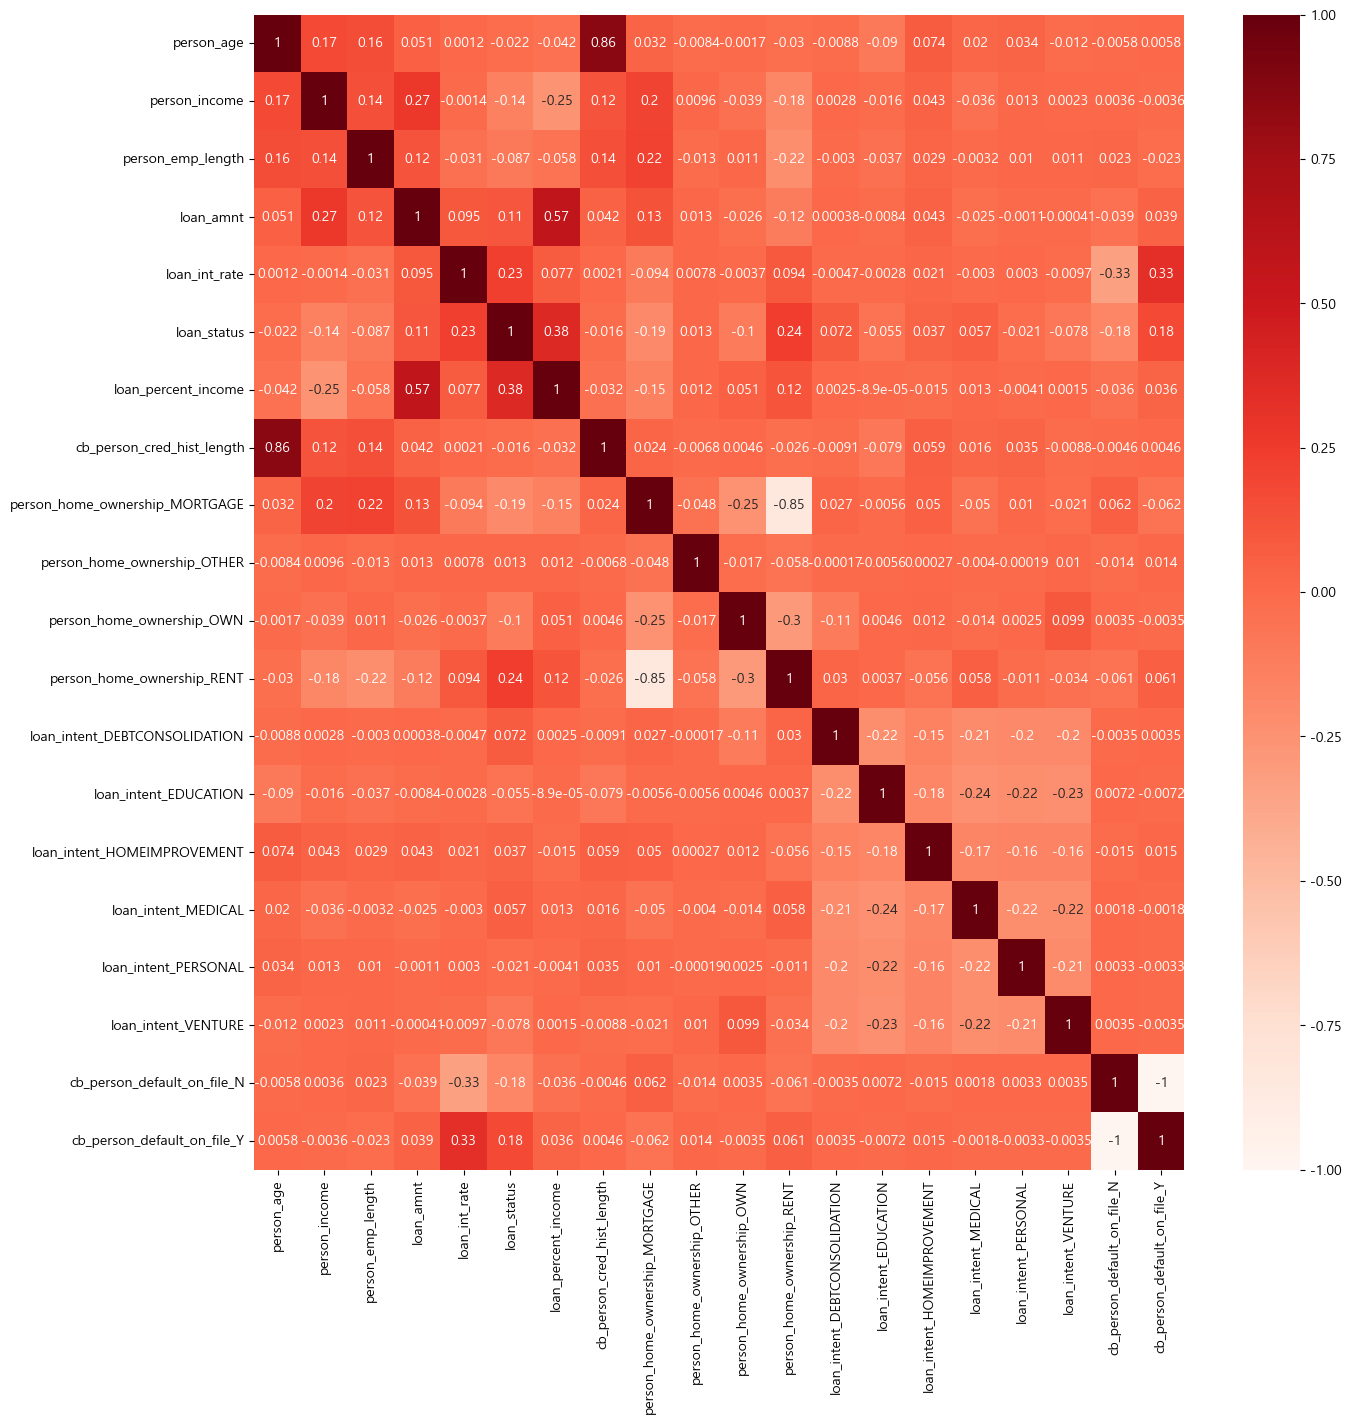

In [42]:
plt.figure(figsize=(15, 15))  
sns.heatmap(corr_x, annot=True, cmap='Reds')  

- 아래는 0.6보다 상관계수 높은 x쌍을 출력하는 코드
- dummy 변수들을 제외하고 남은건 cb_person_cred_hist_length와 person_age

In [43]:
# 예시: 상관계수 행렬
corr_matrix = X.corr().abs()  # 절대값으로 변환

# 상삼각 행렬(자기 자신과 중복 제거)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 절대값이 0.6 이상인 컬럼쌍 추출
high_corr_pairs = [
    (col, idx, upper.loc[idx, col])
    for col in upper.columns
    for idx in upper.index
    if pd.notnull(upper.loc[idx, col]) and upper.loc[idx, col] > 0.6
]

# 보기 좋게 정렬
high_corr_pairs.sort(key=lambda x: -x[2])

# 출력
for a, b, corr in high_corr_pairs:
    print(f"{a} - {b}: {corr:.3f}")

cb_person_default_on_file_Y - cb_person_default_on_file_N: 1.000
cb_person_cred_hist_length - person_age: 0.859
person_home_ownership_RENT - person_home_ownership_MORTGAGE: 0.846


#### 위에서 상관계수 값 높은거 산점도 그리기  

- cb_person_cred_hist_length : 개인의 신용거래가 처음 시작된 이후 경과한 기간
- 그렇기때문에 당연히 person_age와 비례할듯
- 일단은 둘 중 하나의 변수 제거하지 않고 가보자 

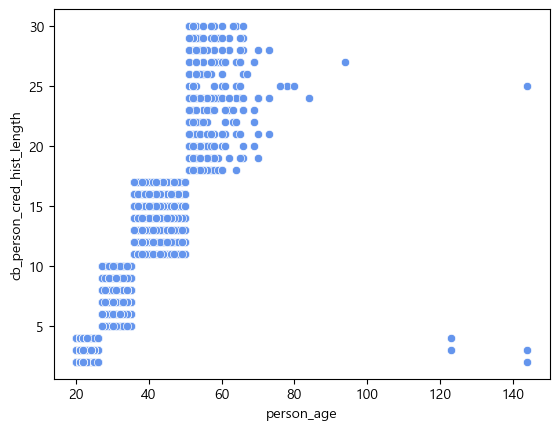

In [44]:
sns.scatterplot(data=df, x='person_age', y='cb_person_cred_hist_length', color='cornflowerblue')  
plt.show() 

#### 이외 컬럼 간 관계 파악  

- box plot 및 히스토그램에서 너무 분포가 잘 구분된 변수인 'loan_int_rate'로 산점도 그려보기
- 위 box plot과 히스토그램과 같이 분포가 잘 구분됨  

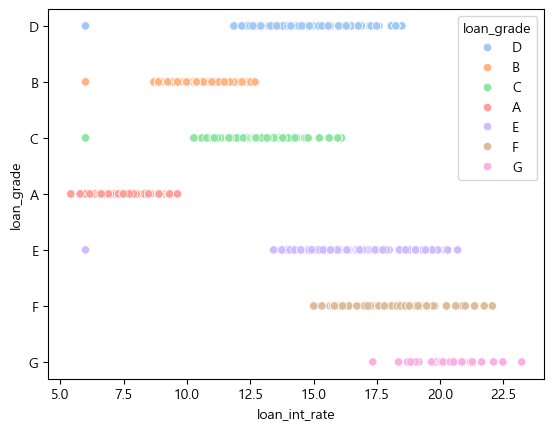

In [45]:
sns.scatterplot(data=df, x='loan_int_rate', y='loan_grade', hue='loan_grade', palette='pastel')  
plt.show() 

- loan_status와 loan_grade 간 관계 보기 

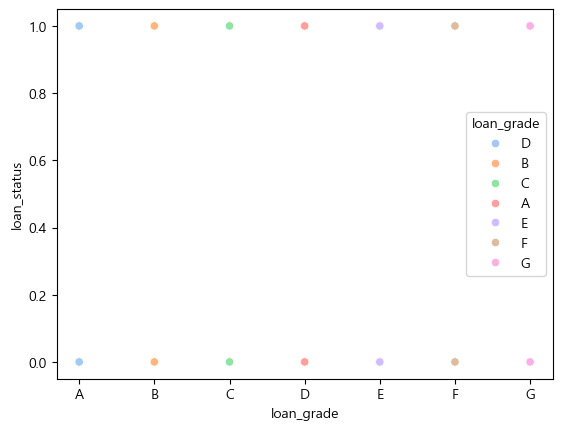

In [68]:
order = sorted(df['loan_grade'].unique())
# print(order)
sns.scatterplot(data=df, x='loan_grade', y='loan_status', hue='loan_grade', palette='pastel')
plt.xticks(ticks=range(len(order)), labels=order)
plt.show() 

- 채무 불이행한 경우가 1, 불이행 없는 것이 0
- 신용등급이 안좋아질수록 채무 불이행한 사람이 많아짐  

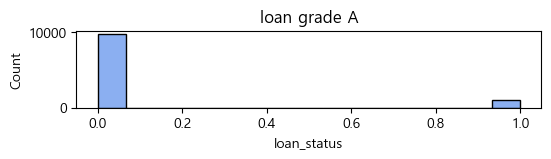

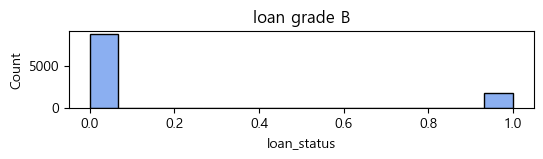

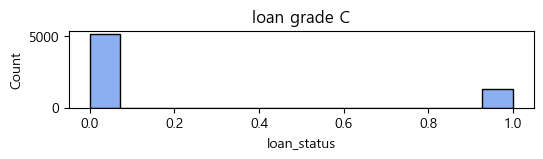

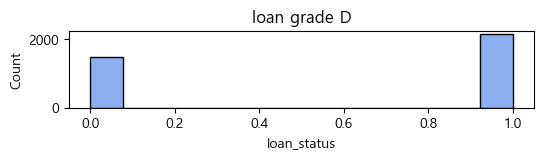

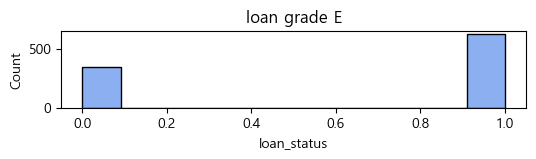

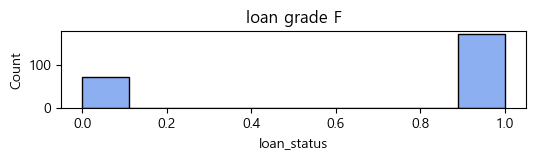

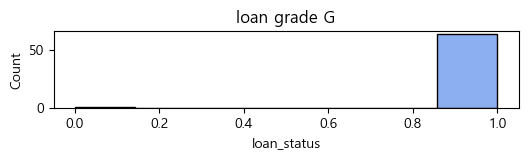

In [82]:
for idx, now_grade in enumerate(sorted(df.loan_grade.unique())):
    plt.figure(figsize=(6,1))
    tmp = df[df['loan_grade'] == now_grade]
    sns.histplot(data=tmp, x='loan_status', color='cornflowerblue')
    plt.title('loan grade {}'.format(now_grade))
    plt.show()